In [4]:
using Pkg
Pkg.activate("/home/camillaberti/tp4-exercises/julia")
Pkg.status()

  Activating project at `~/tp4-exercises/julia`


Status `~/tp4-exercises/julia/Project.toml`
⌃ [6e4b80f9] BenchmarkTools v1.6.3
  [13f3f980] CairoMakie v0.15.9
  [7a1cc6ca] FFTW v1.10.0
  [7073ff75] IJulia v1.34.4
⌃ [1dea7af3] OrdinaryDiffEq v6.108.0
  [6c2fb7c5] QuantumToolbox v0.44.0
⌃ [789caeaf] StochasticDiffEq v6.100.0
Info Packages marked with ⌃ have new versions available and may be upgradable.


In [5]:
using QuantumToolbox
using CairoMakie
using FFTW

In [6]:
N = 20 # Fock space truncated dimension
#greek letters in julia: \omega should work, maybe not in the notebook, or switch to the greek keyboard, but it is a nice feature we can use symbols like tensor pronduct
ωa = 1
ωc = 1 * ωa    # considering cavity and atom are in resonance, detuning = 0
σz = sigmaz() ⊗ qeye(N) # order of tensor product should be consistent throughout, sigmaz already included in the library, if we use qeye we have the quantum object that contains the matrix describing the identity
a  = qeye(2)  ⊗ destroy(N)  #other fundamental function, destroy and create are for annihilation/creation operator
Ω  = 0.5
σ  = sigmam() ⊗ qeye(N)

Ha = ωa / 2 * σz
Hc = ωc * a' * a # the symbol `'` after a `QuantumObject` act as adjoint
Hint = Ω * (σ * a' + σ' * a) #Ω is the vacuum Rabi frequency, it measures the strength of the coupling

Htot  = Ha + Hc + Hint #time is in unit of 1/ωa 


Quantum Object:   type=Operator()   dims=([2, 20], [2, 20])   size=(40, 40)   ishermitian=true
40×40 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 78 stored entries:
⎡⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠈⠢⎥
⎢⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠈⠢⡀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⎦

In [7]:
e_ket = basis(2,0) 
alpha = 3
ψ0 = e_ket ⊗ coherent(N, alpha) #second parameter is alpha

tlist = 0:0.1:200 # a list of time points of interest

println("Collapse time t_c = $(π/Ω)")
println("Revival time t_r = $(4*π*alpha/Ω)")
# define a list of operators whose expectation value dynamics exhibit Rabi oscillation
eop_ls = [
    a' * a,                      # number operator of cavity, already defined in the total hilbert space
    (e_ket * e_ket') ⊗ qeye(N), # excited state population in atom
]

sol = sesolve(Htot , ψ0, tlist; e_ops = eop_ls)
sol

Collapse time t_c = 6.283185307179586
Revival time t_r = 75.39822368615503


[sesolve] 100%|███████████████████████████| Time: 0:00:12 ( 6.36 ms/it)


Solution of time evolution
(return code: Success)
--------------------------
num_states = 1
num_expect = 2
ODE alg.: OrdinaryDiffEqVerner.Vern7{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), Static.False, Val{false}}(OrdinaryDiffEqCore.trivial_limiter!, OrdinaryDiffEqCore.trivial_limiter!, static(false), Val{false}())
abstol = 1.0e-8
reltol = 1.0e-6


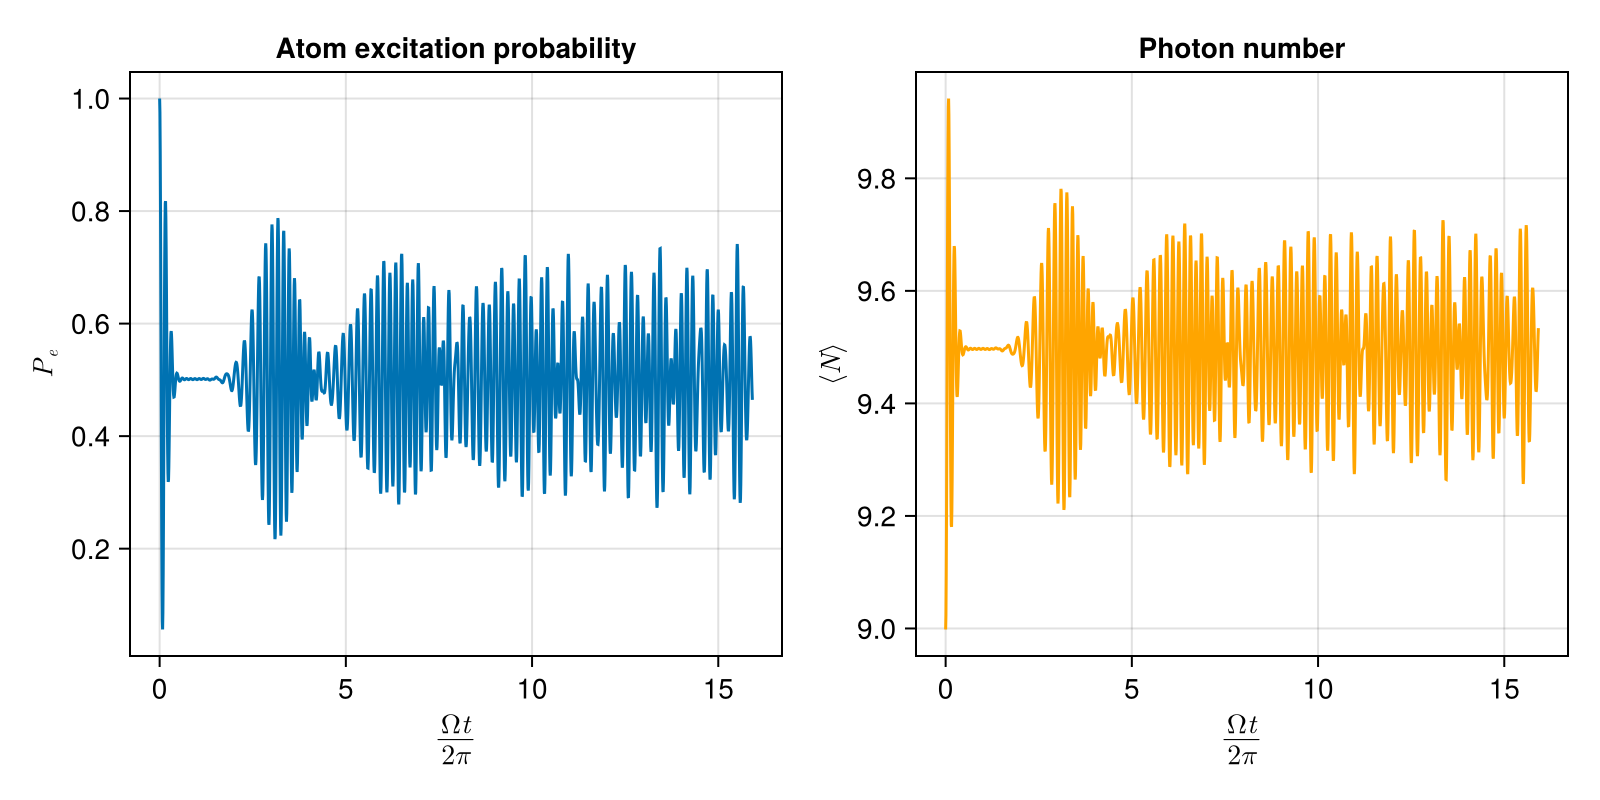

In [8]:
n = real.(sol.expect[1, :])
e = real.(sol.expect[2, :])
tplot = tlist *Ω/(2*π)
#=
fig_se = Figure()
ax_se = Axis(
    fig_se[1, 1],
    xlabel = L"time $[1/\omega_a]$", 
    ylabel = "expectation value", 
    xlabelsize = 15, 
    ylabelsize = 15,
)
ylims!(ax_se,0,1)
xlims!(ax_se, 0, 20)
lines!(ax_se, tplot, n, label = L"$\langle a^\dagger a \rangle$")
lines!(ax_se, tplot, e, label = L"$P_e$")
axislegend(ax_se; position = :rt, labelsize = 15)
fig_se
=#

fig = Figure(size=(800, 400))

ax1 = Axis(fig[1, 1], xlabel=L"$\frac{\Omega t}{2\pi}$", ylabel=L"P_e", title = "Atom excitation probability")
ax2 = Axis(fig[1, 2], xlabel=L"$\frac{\Omega t}{2\pi}$", ylabel=L"$\langle N \rangle$", title="Photon number")

lines!(ax1, tplot, e, label=L"P_e")
lines!(ax2, tplot, n, color = :orange, label=L"$\langle a^\dagger a \rangle$")

fig

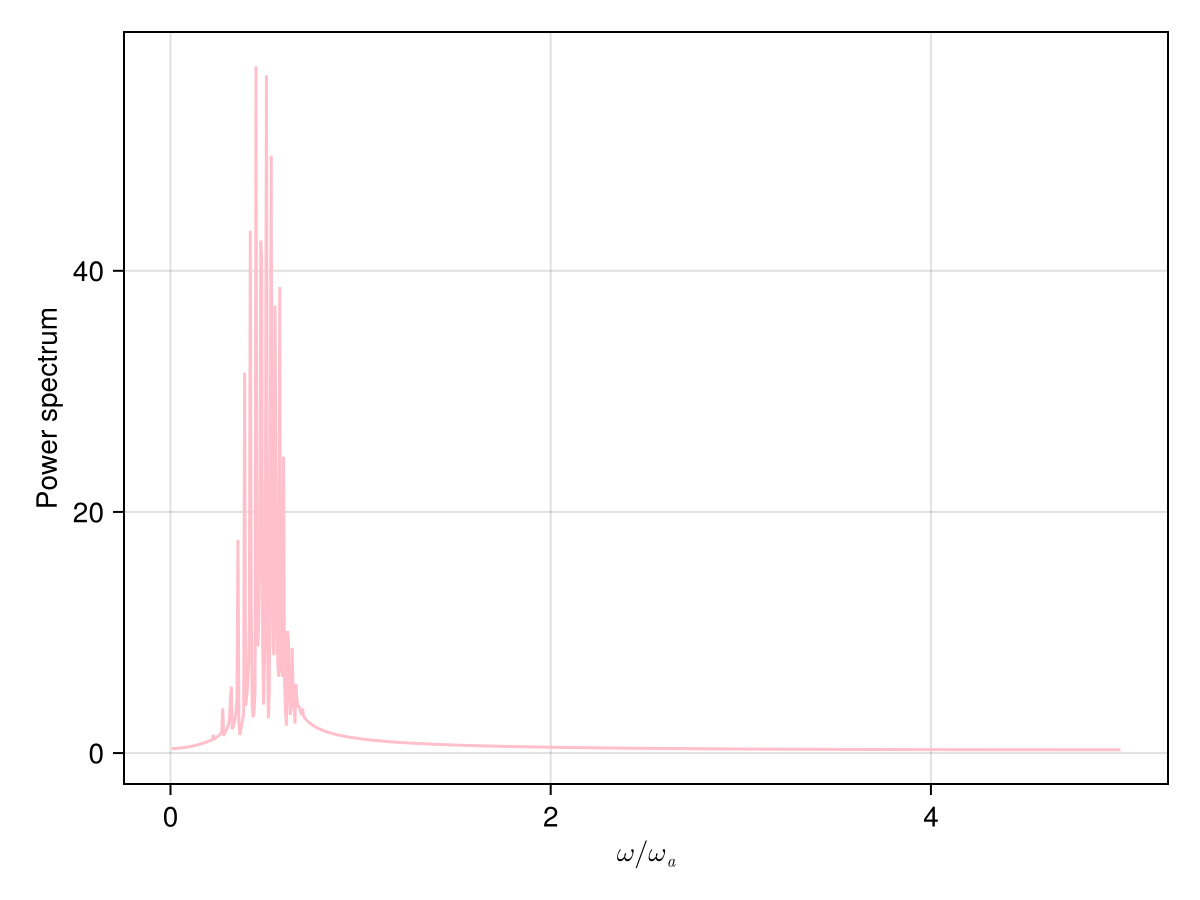

In [12]:
dt    = tlist[2] - tlist[1]
N     = length(tlist)

yf    = fft(n)   # FFT of ⟨a†a⟩
freqs = fftfreq(N, 1/dt)            # in units of ωa (since tlist is in 1/ωa)

# Keep only positive frequencies
pos       = freqs .> 0
freqs_pos = freqs[pos]
power_pos = abs.(yf[pos])

fig = Figure()
ax  = Axis(fig[1,1], xlabel=L"\omega / \omega_a", ylabel="Power spectrum")
lines!(ax, freqs_pos, power_pos, color=:pink)
fig